In [1]:
import sys
sys.path.insert(0, '../Results')
sys.path.insert(0, '../../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from python_utils.visualization_utils import perc, SetPlotRC, ApplyFont, format_results_for_jupyter_and_latex, print_experiment_summary_hyperparams
from python_utils.visualization_utils import plot_pcl_convergence_ci, plot_pcl_convergence_w_quantiles, plot_pcl_convergence_boxplot

import warnings
warnings.filterwarnings("ignore")

In [2]:
if not os.path.exists("Figures"):
    os.mkdir("Figures")

# Synthetic CATE Experiment with Log Cosh loss Function

In [3]:
df_doubly_robustNME = pd.read_csv(r"../Results/CATE_Synthetic_Experiment/DRPCLNET_SyntheticCATE_Results_with_SGD_and_log_cosh_2000_5000_10000_15000_20000_2026-04-24_13-21-28.csv")
df_KPV = pd.read_csv(r"../Results/CATE_Synthetic_Experiment/KPV_Synthetic_CATE_Results_2000_5000_10000_15000_20000_2026-04-08_19-59-03.csv")
df_results = pd.concat([df_doubly_robustNME, df_KPV], axis = 0)
df_doubly_robustNME.tail()

,Algorithm,Data_Size,Seed,Causal_MSE,out_experiment_name,out_device,out_disable_first_stage,out_lr_first_stage_base,out_lr_second_stage_ax,out_lr_second_stage_w,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
595,DRPCLNET_Version2,20000,2800,0.000079,outcome_bridge_synthetic_cate_v1,cuda,False,0.0001,0.0001,0.0001,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
596,OutcomeBridgePCLNET,20000,2900,0.000149,outcome_bridge_synthetic_cate_v1,cuda,False,0.0001,0.0001,0.0001,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
597,TreatmentBridgePCLNET,20000,2900,0.001966,outcome_bridge_synthetic_cate_v1,cuda,False,0.0001,0.0001,0.0001,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
598,DRPCLNET_Version1,20000,2900,0.000062,outcome_bridge_synthetic_cate_v1,cuda,False,0.0001,0.0001,0.0001,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
599,DRPCLNET_Version2,20000,2900,0.000054,outcome_bridge_synthetic_cate_v1,cuda,False,0.0001,0.0001,0.0001,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05


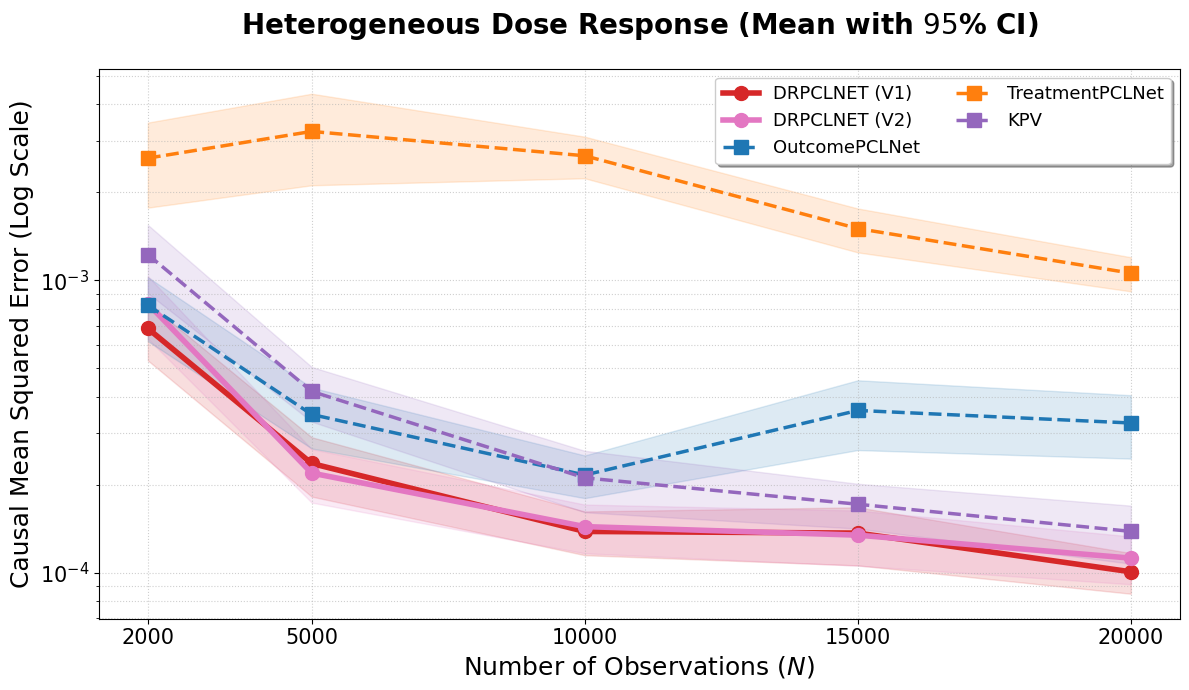

In [4]:
plot_title = f"Heterogeneous Dose Response (Mean with $95$% CI)"
cate_plot = plot_pcl_convergence_ci(df_results, title = plot_title)
plt.savefig('Figures/DRPCLNET_LowDimCATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
cate_plot.show()

In [5]:
# plot_title = "Heterogeneous Dose Response"
# cate_plot = plot_pcl_convergence_w_quantiles(df_results, title = plot_title)
# # plt.savefig('Figures/DRPCLNET_LowDimCATE_Comparison.pdf', format='pdf', bbox_inches = 'tight')
# cate_plot.show()

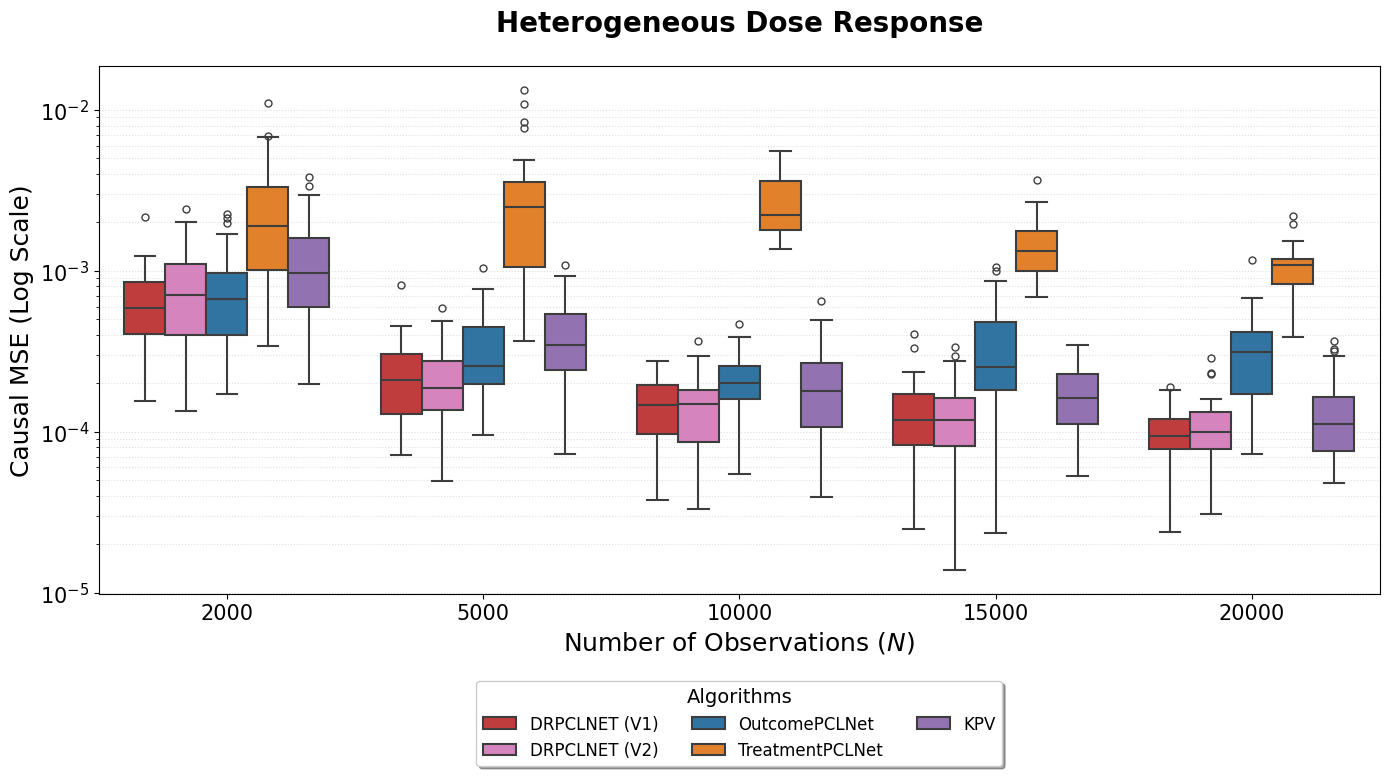

In [6]:
plot_title = "Heterogeneous Dose Response"
cate_boxplot = plot_pcl_convergence_boxplot(df_results, title = plot_title)
# plt.savefig('Figures/DRPCLNET_LowDimCATE_Comparison_BoxPlot.pdf', format='pdf', bbox_inches = 'tight')
cate_boxplot.show()

In [7]:
format_results_for_jupyter_and_latex(df_results, "CATE", precision=6)

--- Jupyter Visual Preview ---


In [8]:
# print_experiment_summary_hyperparams(df_doubly_robustNME);

# Synthetic CATE Experiment with Other Loss Functions

In [9]:
df_NME_huber = pd.read_csv(r"../Results/CATE_Synthetic_Experiment/DRPCLNET_SyntheticCATE_Results_with_SGD_and_huber_2000_5000_10000_15000_20000_2026-04-24_13-51-46.csv")

In [10]:
format_results_for_jupyter_and_latex(df_NME_huber, "CATE", precision=6)

--- Jupyter Visual Preview ---


In [11]:
df_NME_mse = pd.read_csv(r"../Results/CATE_Synthetic_Experiment/DRPCLNET_SyntheticCATE_Results_with_SGD_and_MSE_2000_5000_10000_15000_20000_2026-04-24_13-51-33.csv")

In [12]:
format_results_for_jupyter_and_latex(df_NME_mse, "CATE", precision=6)

--- Jupyter Visual Preview ---


In [13]:
df_NME_mse_closed_form = pd.read_csv(r"../Results/CATE_Synthetic_Experiment/DRPCLNET_SyntheticCATE_Results_with_ClosedForm_2000_5000_10000_15000_20000_2026-04-24_13-51-46.csv")

In [14]:
format_results_for_jupyter_and_latex(df_NME_mse_closed_form, "CATE", precision=6)

--- Jupyter Visual Preview ---


In [15]:
df_NME_misspecified = pd.read_csv(r"../Results/CATE_Synthetic_Experiment/DRPCLNET_SyntheticCATE_Misspecified_Noisy_Proxies_Results_with_SGD_and_log_cosh_2026-04-27_14-34-13.csv")
df_NME_misspecified.tail()

,Algorithm,Data_Size,Seed,Scenario,Causal_MSE,Estimated_Response,Treatment_Grid,Ground_Truth_Response,out_experiment_name,out_device,...,treat_negative_penalty,third_lr,third_weight_decay,third_n_epochs,third_gap_penalty_weight,third_log_per_epoch,third_input_dim,third_output_dim,third_hidden_dims,third_dropout_rate
355,DRPCLNET_Version2,2000,2800,both_misspecified,0.001031,"[0.012621335685253143, 0.007767714560031891, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.0, -0.0004438229927267725, -0.001715192498...",outcome_bridge_synthetic_cate_v1,cuda,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
356,OutcomeBridgePCLNET,2000,2900,both_misspecified,0.000716,"[0.007673226296901703, 0.0056683942675590515, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.0, -0.0004438229927267725, -0.001715192498...",outcome_bridge_synthetic_cate_v1,cuda,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
357,TreatmentBridgePCLNET,2000,2900,both_misspecified,0.086299,"[-0.016709700226783752, -0.026353761553764343,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.0, -0.0004438229927267725, -0.001715192498...",outcome_bridge_synthetic_cate_v1,cuda,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
358,DRPCLNET_Version1,2000,2900,both_misspecified,0.000950,"[0.0016557970084249973, -0.0005028592422604561...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.0, -0.0004438229927267725, -0.001715192498...",outcome_bridge_synthetic_cate_v1,cuda,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05
359,DRPCLNET_Version2,2000,2900,both_misspecified,0.003371,"[-0.08639449626207352, -0.08599592000246048, -...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[-0.0, -0.0004438229927267725, -0.001715192498...",outcome_bridge_synthetic_cate_v1,cuda,...,10.0,0.001,0.000001,100.0,0.0,10.0,2.0,1.0,"[64, 128]",0.05


In [16]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = r"../Results/CATE_Synthetic_Experiment/DRPCLNET_SyntheticCATE_Misspecified_Noisy_Proxies_Results_with_SGD_and_log_cosh_2026-04-27_14-34-13.csv"
df = pd.read_csv(csv_path)

def parse_array(x):
    return np.array(json.loads(x), dtype=float).reshape(-1)

df["est"] = df["Estimated_Response"].apply(parse_array)
df["truth"] = df["Ground_Truth_Response"].apply(parse_array)
df["grid"] = df["Treatment_Grid"].apply(parse_array)

# Recompute MSE as a sanity check
df["MSE_check"] = df.apply(lambda r: np.mean((r["est"] - r["truth"]) ** 2), axis=1)
print("max MSE mismatch:", np.max(np.abs(df["Causal_MSE"] - df["MSE_check"])))

mse_table = (
    df.groupby(["Scenario", "Data_Size", "Algorithm"])
      .agg(
          mean_mse=("Causal_MSE", "mean"),
          se_mse=("Causal_MSE", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
          n=("Causal_MSE", "count"),
      )
      .reset_index()
)

mse_table["mean ± se"] = mse_table.apply(
    lambda r: f"{r['mean_mse']:.4g} ± {r['se_mse']:.2g}",
    axis=1,
)

mse_pivot = mse_table.pivot_table(
    index=["Scenario", "Data_Size"],
    columns="Algorithm",
    values="mean ± se",
    aggfunc="first",
)

mse_pivot

max MSE mismatch: 9.963817965141786e-17


,Algorithm,DRPCLNET_Version1,DRPCLNET_Version2,OutcomeBridgePCLNET,TreatmentBridgePCLNET
Scenario,Data_Size,,,,
both_misspecified,2000,0.0008189 ± 0.00011,0.001781 ± 0.00034,0.0007287 ± 9.3e-05,0.05641 ± 0.0038
outcome_misspecified,2000,0.0006721 ± 7.8e-05,0.0007945 ± 0.00013,0.0008773 ± 0.00011,0.002544 ± 0.00029
treatment_misspecified,2000,0.001634 ± 0.00025,0.003162 ± 0.00057,0.001423 ± 0.00017,0.05562 ± 0.0036


Saved: Figures/cate_misspecification_treatment_misspecified.pdf


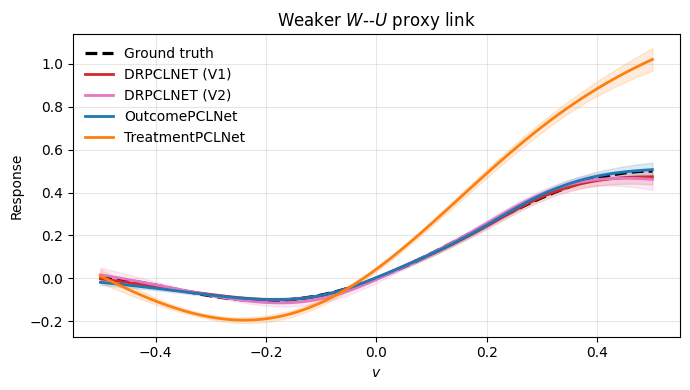

Saved: Figures/cate_misspecification_outcome_misspecified.pdf


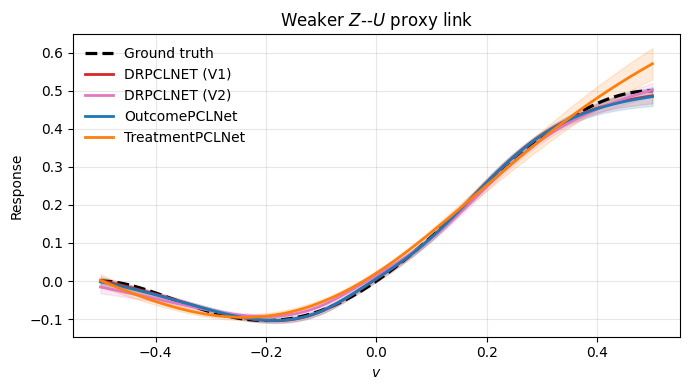

Saved: Figures/cate_misspecification_both_misspecified.pdf


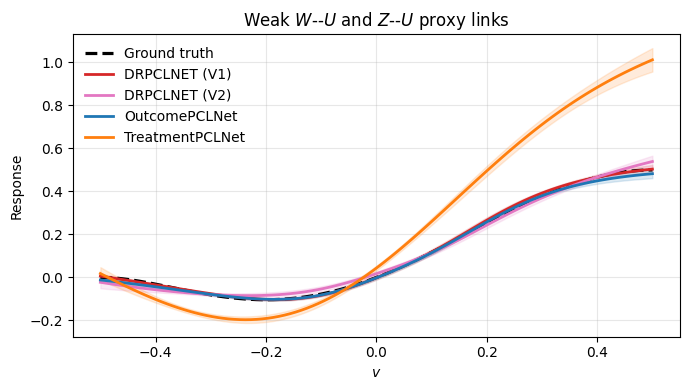

['Figures/cate_misspecification_treatment_misspecified.pdf',
 'Figures/cate_misspecification_outcome_misspecified.pdf',
 'Figures/cate_misspecification_both_misspecified.pdf']

In [17]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# --- Global Configuration ---
LEGEND_ORDER = [
    "DRPCLNET (V1)", 
    "DRPCLNET (V2)", 
    "OutcomePCLNet", 
    "TreatmentPCLNet", 
    "PKDR", 
    "DRKPV", 
    "KPV"
]

COLOR_PALETTE = {
    "DRPCLNET (V1)": "#d62728",   # Red
    "DRPCLNET (V2)": "#e377c2",   # Pink
    "OutcomePCLNet": "#1f77b4",   # Blue
    "TreatmentPCLNet": "#ff7f0e", # Orange
    "PKDR": "#7f7f7f",            # Gray
    "DRKPV": "#2ca02c",           # Green
    "KPV": "#9467bd",             # Purple
}

TITLE_MAP = {
    "treatment_misspecified": r"Weaker $W$--$U$ proxy link",
    "outcome_misspecified": r"Weaker $Z$--$U$ proxy link",
    "both_misspecified": r"Weak $W$--$U$ and $Z$--$U$ proxy links",
}

ALGO_LABEL_MAP = {
    "DRPCLNET_Version1": "DRPCLNET (V1)",
    "DRPCLNET_Version2": "DRPCLNET (V2)",
    "DRPCLNET (V1)": "DRPCLNET (V1)",
    "DRPCLNET (V2)": "DRPCLNET (V2)",

    "OutcomeBridgePCLNET": "OutcomePCLNet",
    "TreatmentBridgePCLNET": "TreatmentPCLNet",
    "OutcomePCLNet": "OutcomePCLNet",
    "TreatmentPCLNet": "TreatmentPCLNet",

    "PKDR": "PKDR",
    "DRKPV": "DRKPV",
    "KPV": "KPV",
}

def normalize_algo_name(name):
    return ALGO_LABEL_MAP.get(name, str(name))

def as_1d_array(x):
    return np.asarray(x, dtype=float).reshape(-1)

def safe_filename(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9_\-]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text

def plot_curves(df, scenario, data_size, save_dir="Figures/CATE_Misspecification", show=True):
    sub = df[(df["Scenario"] == scenario) & (df["Data_Size"] == data_size)].copy()

    if sub.empty:
        print(f"No rows found for scenario={scenario}, data_size={data_size}")
        return None

    os.makedirs(save_dir, exist_ok=True)

    sub["_AlgorithmLabel"] = sub["Algorithm"].apply(normalize_algo_name)

    fig, ax = plt.subplots(figsize=(7, 4))

    # Ground truth: use first row
    truth = as_1d_array(sub.iloc[0]["truth"])

    # Actual CATE heterogeneity grid: v uniformly sampled from -0.5 to 0.5
    x = np.linspace(-0.5, 0.5, len(truth))

    ax.plot(x, truth, "k--", linewidth=2.3, label="Ground truth")

    available_labels = list(sub["_AlgorithmLabel"].unique())
    ordered_labels = [alg for alg in LEGEND_ORDER if alg in available_labels]
    ordered_labels += [alg for alg in available_labels if alg not in ordered_labels]

    for alg_label in ordered_labels:
        alg_rows = sub[sub["_AlgorithmLabel"] == alg_label]
        if alg_rows.empty:
            continue

        curves = np.stack(alg_rows["est"].apply(as_1d_array).to_numpy())

        mean = curves.mean(axis=0)
        se = (
            curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])
            if curves.shape[0] > 1
            else np.zeros_like(mean)
        )

        color = COLOR_PALETTE.get(alg_label, None)

        ax.plot(
            x,
            mean,
            label=alg_label,
            color=color,
            linewidth=2.0,
        )
        ax.fill_between(
            x,
            mean - 1.96 * se,
            mean + 1.96 * se,
            color=color,
            alpha=0.15,
        )

    ax.set_title(TITLE_MAP.get(scenario, scenario.replace("_", " ").title()))
    ax.set_xlabel(r"$v$")
    ax.set_ylabel("Response")
    ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    legend_labels = ["Ground truth"] + [alg for alg in LEGEND_ORDER if alg in label_to_handle]
    legend_labels += [lab for lab in labels if lab not in legend_labels]

    ax.legend(
        [label_to_handle[lab] for lab in legend_labels],
        legend_labels,
        frameon=False,
    )

    fig.tight_layout()

    filename = f"cate_misspecification_{safe_filename(scenario)}.pdf"
    save_path = os.path.join(save_dir, filename)

    fig.savefig(save_path, format="pdf", bbox_inches="tight")
    print(f"Saved: {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path

saved_paths = []
for scenario in df["Scenario"].unique():
    path = plot_curves(
        df,
        scenario=scenario,
        data_size=2000,
        save_dir="Figures",
        show=True,
    )
    if path is not None:
        saved_paths.append(path)

saved_paths